In [42]:
# Import all necessary libraries for data handling, visualisation and machine learning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing and model selection
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Logistic Regression algorithm
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

print('All libraries imported!')

All libraries imported!


In [13]:
df = pd.read_csv('../Dataset/Heart_Disease_DataSet.csv', na_values='?')

print(f'Rows    : {df.shape[0]}')
print(f'Columns : {df.shape[1]}')
df.head()

Rows    : 1025
Columns : 14


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [14]:
# Count missing values per column
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing: 0


In [15]:
# Display the actual rows that contain missing values
# so we can see exactly which patients are affected
print(df[df.isnull().any(axis=1)])

Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target]
Index: []


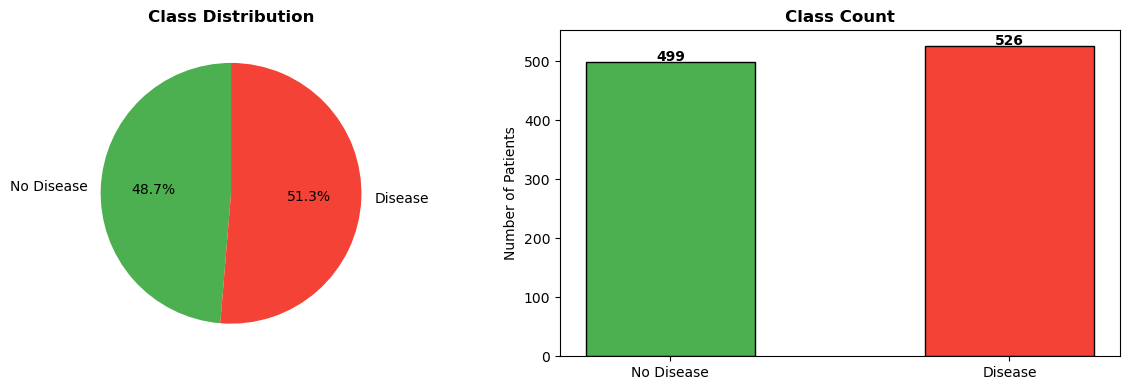

In [16]:
binary_preview = (df['target'] > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
axes[0].pie(
    binary_preview.value_counts().sort_index(),
    labels=['No Disease', 'Disease'],
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336'],
    startangle=90
)
axes[0].set_title('Class Distribution', fontweight='bold')

# Bar chart
counts = binary_preview.value_counts().sort_index()
bars = axes[1].bar(['No Disease', 'Disease'], counts,
                   color=['#4CAF50', '#F44336'], edgecolor='black', width=0.5)
axes[1].set_ylabel('Number of Patients')
axes[1].set_title('Class Count', fontweight='bold')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(int(bar.get_height())), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

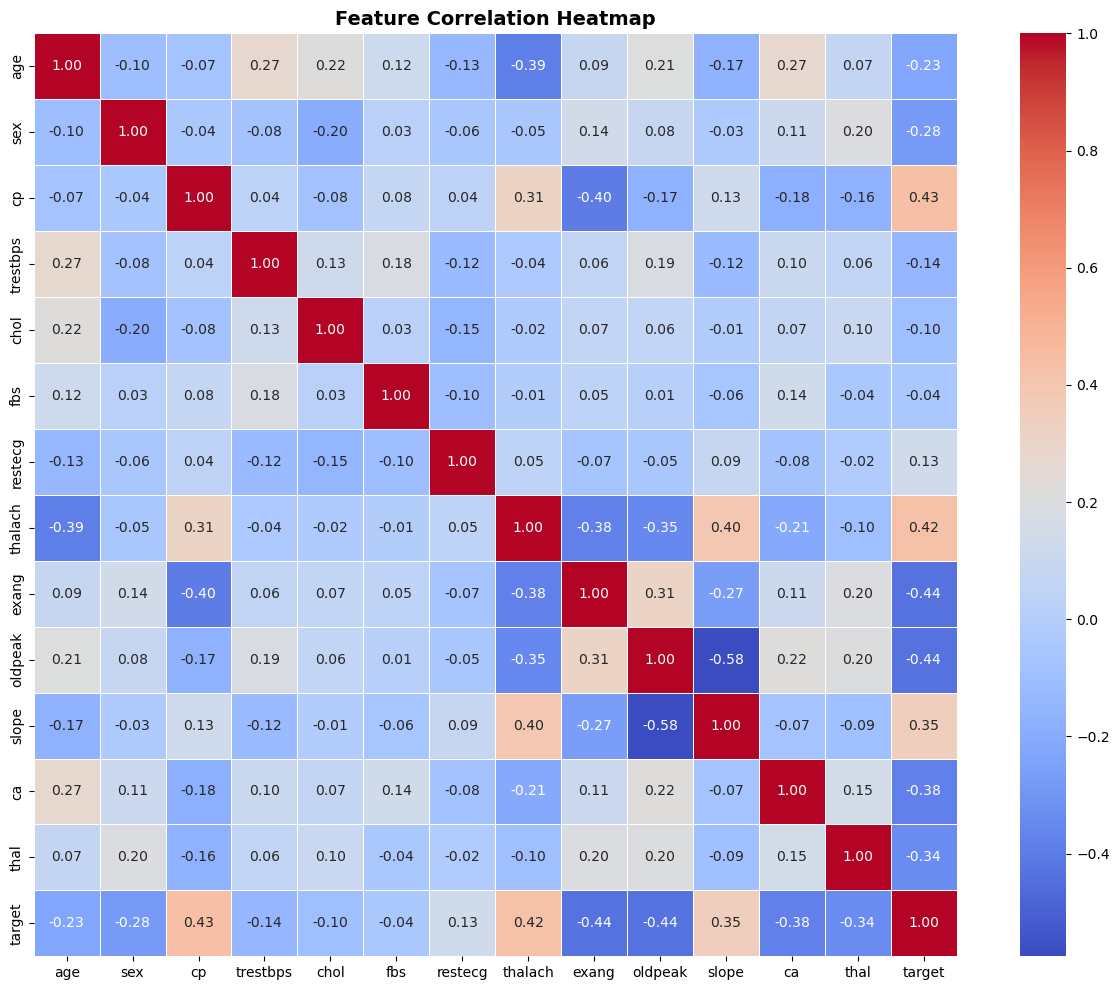

In [17]:
corr_df = df.copy()
corr_df['target'] = binary_preview



In [18]:
# Convert target from 0-4 scale to binary 0 or 1
# 0 = no disease, 1 = disease present (any stage)
# This simplifies the problem to binary classification
df['target'] = (df['target'] > 0).astype(int)

print(f'No Disease (0) : {(df["target"]==0).sum()} patients')
print(f'Disease    (1) : {(df["target"]==1).sum()} patients')

No Disease (0) : 499 patients
Disease    (1) : 526 patients


In [19]:
# Convert ca and thal to int after median fill (they became floats)
df['ca']   = df['ca'].astype(int)
df['thal'] = df['thal'].astype(int)

# One-hot encode categorical columns so the model does not assume
# higher numbers mean more importance
# drop_first=True removes one column per feature to avoid the dummy variable trap
df = pd.get_dummies(df, columns=['cp', 'restecg', 'slope', 'ca', 'thal'], drop_first=True)

print(f'✅ Encoding done. New shape: {df.shape}')

✅ Encoding done. New shape: (1025, 23)


In [20]:
# X contains all input features (everything except target)
# y contains only the target column (what we want to predict)
X = df.drop('target', axis=1)
y = df['target']

print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')

X shape : (1025, 22)
y shape : (1025,)


In [22]:
# Split data into 80% training and 20% testing
# stratify=y ensures both splits have the same ratio of 0s and 1s
# random_state=42 ensures everyone on the team gets the same split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scale features so all columns are on the same scale (mean=0, std=1)
# fit_transform on training data only to avoid data leakage
# transform applies the same scale to test data without learning from it
scaler  = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test_raw),      columns=X.columns)

print(f'✅ Split done.')
print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

✅ Split done.
Training samples : 820
Testing  samples : 205


In [26]:
# Split data into 80% training and 20% testing
# stratify=y ensures both splits have the same ratio of 0s and 1s
# random_state=42 ensures everyone on the team gets the same split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scale features so all columns are on the same scale (mean=0, std=1)
# fit_transform on training data only to avoid data leakage
# transform applies the same scale to test data without learning from it
scaler  = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test_raw),      columns=X.columns)

print(f'✅ Split done.')
print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

✅ Split done.
Training samples : 820
Testing  samples : 205


In [27]:
# Train Logistic Regression on the training data
# C=1.0      → default regularisation strength
# lbfgs      → efficient solver for small datasets
# max_iter   → maximum iterations for the solver to converge
# random_state=42 → ensures reproducibility
lr_model = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print('✅ Model trained!')

✅ Model trained!


In [37]:


# 2. TRAIN & PREDICT 
# Make sure this runs BEFORE calculating metrics


lr_pred       = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]




In [31]:

lr_accuracy  = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall    = recall_score(y_test, lr_pred)
lr_f1        = f1_score(y_test, lr_pred)
lr_auc       = roc_auc_score(y_test, lr_pred_proba)   # ← This is AUC-ROC

# Print all metrics nicely
print("=== Logistic Regression Performance ===")
print(f"Accuracy  : {lr_accuracy:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1 Score  : {lr_f1:.4f}")
print(f"AUC-ROC   : {lr_auc:.4f}")


=== Logistic Regression Performance ===
Accuracy  : 0.8683
Precision : 0.8482
Recall    : 0.9048
F1 Score  : 0.8756
AUC-ROC   : 0.9440



Confusion Matrix:
[[83 17]
 [10 95]]


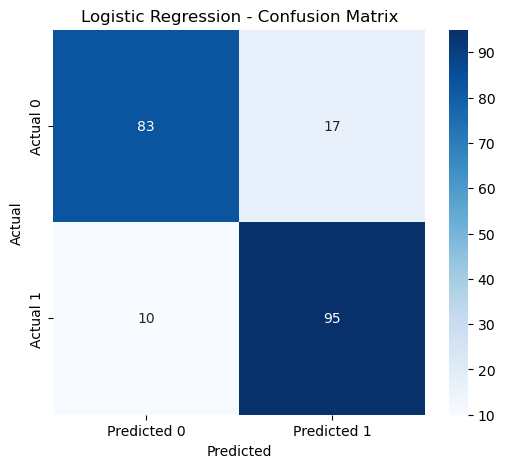

In [32]:
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, lr_pred)
print(cm)

# Nice visualization of Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


In [33]:
print("\nDetailed Classification Report:")
print(classification_report(y_test, lr_pred))


Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86       100
           1       0.85      0.90      0.88       105

    accuracy                           0.87       205
   macro avg       0.87      0.87      0.87       205
weighted avg       0.87      0.87      0.87       205



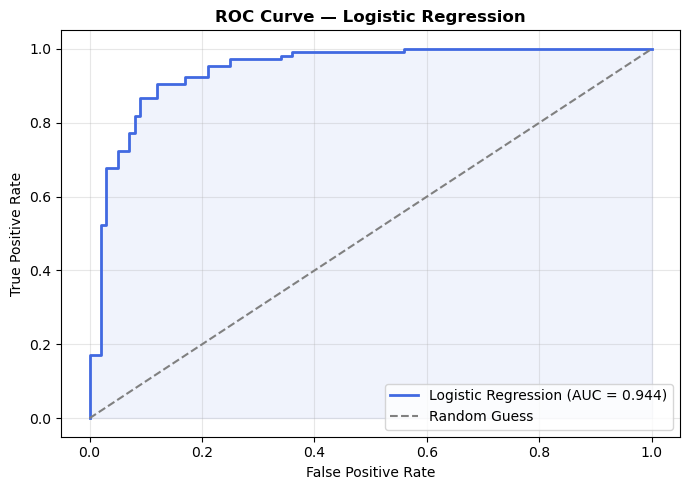

In [39]:
# Plot the ROC curve to show the model's ability to separate
# sick from healthy patients across all decision thresholds
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, color='royalblue', lw=2,
         label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random Guess')
plt.fill_between(fpr_lr, tpr_lr, alpha=0.08, color='royalblue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_LR.png', dpi=150, bbox_inches='tight')
plt.show()

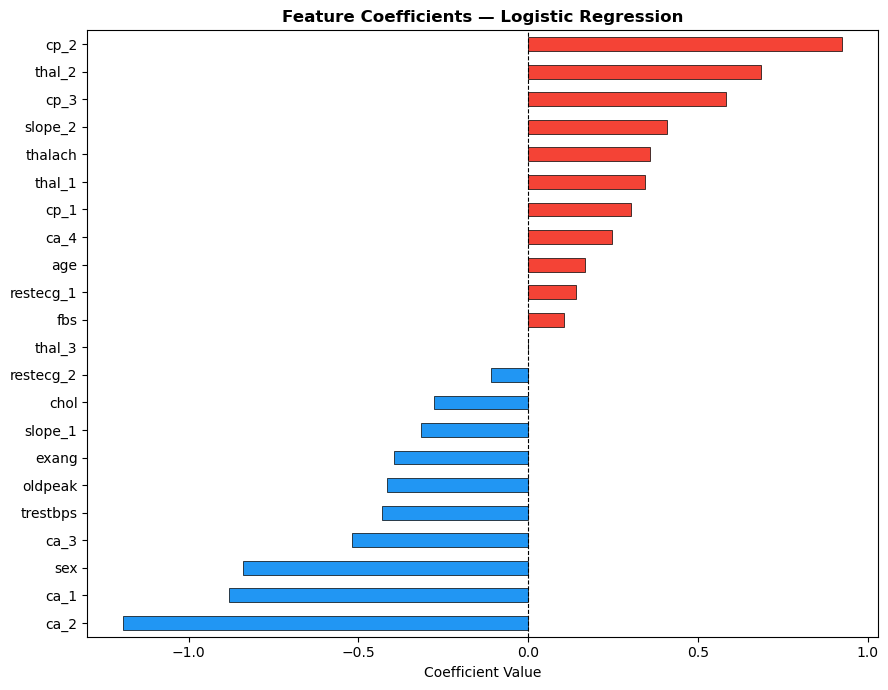

In [40]:
# Plot the coefficient of each feature to show its influence on the prediction
# Red  = increases probability of disease
# Blue = decreases probability of disease
coefficients = pd.Series(lr_model.coef_[0], index=X.columns).sort_values()
colors = ['#F44336' if c > 0 else '#2196F3' for c in coefficients]

plt.figure(figsize=(9, 7))
coefficients.plot(kind='barh', color=colors, edgecolor='black', linewidth=0.5)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Coefficients — Logistic Regression', fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('feature_coefficients_LR.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# Run 5-fold cross validation to verify results are reliable
# Pipeline ensures scaling happens inside each fold to avoid data leakage
lr_cv_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42))
])

cv_scores = cross_val_score(lr_cv_pipeline, X, y, cv=5, scoring='accuracy')

for i, score in enumerate(cv_scores, 1):
    print(f'Fold {i}: {score:.4f}')
print(f'\nMean : {cv_scores.mean():.4f}')
print(f'Std  : {cv_scores.std():.4f}')

Fold 1: 0.8780
Fold 2: 0.8537
Fold 3: 0.8927
Fold 4: 0.8537
Fold 5: 0.8293

Mean : 0.8615
Std  : 0.0219


In [ ]:
# Store final metrics in a dictionary for team comparison table
lr_results = {
    'Algorithm' : 'Logistic Regression',
    'Accuracy'  : round(lr_accuracy,  4),
    'Precision' : round(lr_precision, 4),
    'Recall'    : round(lr_recall,    4),
    'F1-Score'  : round(lr_f1,        4),
    'AUC-ROC'   : round(lr_auc,       4),
}

print(lr_results)
print('\nLogistic Regression complete!')